Importing packages

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

c:\Users\weron\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloading csv file bitcoin historical data 

In [2]:
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

file_path = os.path.join(path, "btcusd_1-min_data.csv")

df = pd.read_csv(file_path)

print(df.head())

100%|██████████| 102M/102M [00:03<00:00, 31.4MB/s] 

Extracting files...


      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


Showing based information

In [3]:
print(df.shape, df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7525130 entries, 0 to 7525129
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 344.5 MB
(7525130, 6) None


Checking data for missing values

In [4]:
df.isna().any()

Timestamp    False
Open         False
High         False
Low          False
Close        False
Volume       False
dtype: bool

Checking feature close for negative values - price should be always positive

In [5]:
sum(df["Close"]<0)

0

Changing numeric time entry into timestamps

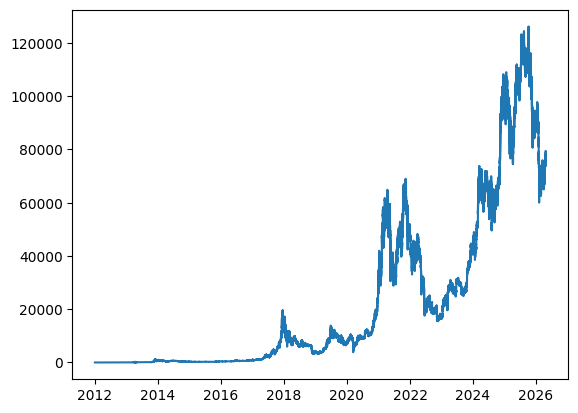

In [6]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"], unit="s")
df = df.set_index("Timestamp").sort_index()
plt.plot(df['Close'])
plt.show()


Calculating hourly data

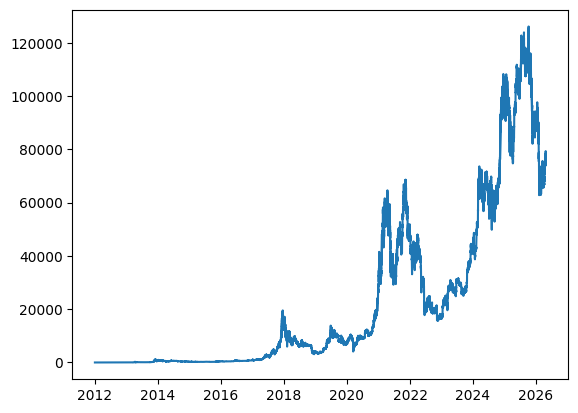

In [7]:
df_hourly = df.resample("1h").agg({
    "Close": "last"
}).dropna()
plt.plot(df_hourly)
plt.show()

Claculating return values in every time step

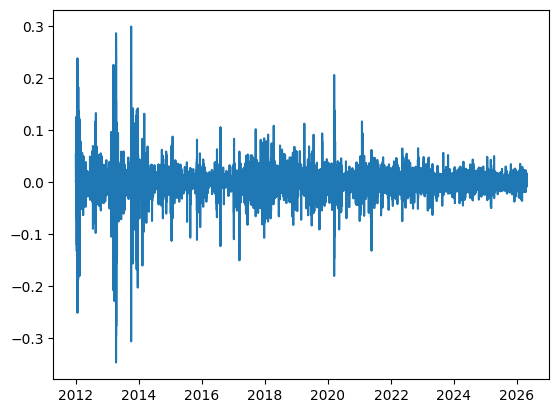

In [8]:
df_hourly["return"] = np.log(df_hourly["Close"]).diff()
df_hourly = df_hourly.dropna()
plt.plot(df_hourly["return"])


Spliting into test and train sets

In [9]:
split_date = "2024-01-01"

df_train = df_hourly.loc[:split_date].copy()
df_test  = df_hourly.loc[split_date:].copy()

Exponential trend smoothing feature "close", Under the hood (with `adjust=False`), it’s the recursive form:

$$
y_t = \alpha x_t + (1 - \alpha) y_{t-1}
$$

where:

- \( x_t \) = `Close` at time *t*  
- \( y_t \) = EMA (`"trend"`)  
- \( $\alpha = \frac{2}{\text{span} + 1} $\)

In [10]:
span =  7*24

df_train["trend"] = df_train["Close"].ewm(span=span, adjust=False).mean()
df_train["detrended"] = df_train["Close"] - df_train["trend"]

df_test["trend"] = df_test["Close"].ewm(span=span, adjust=False).mean()
df_test["detrended"] = df_test["Close"] - df_test["trend"]


Ploting detrended data of close price 

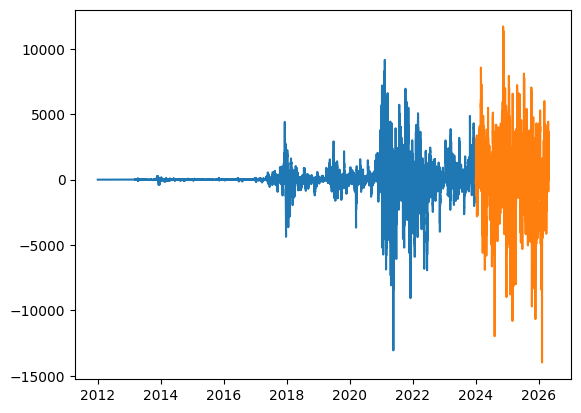

In [11]:
plt.plot(df_train["detrended"])
plt.plot(df_test["detrended"])

Isolating and cuting outliers of returns data

In [12]:
iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=47
)

df_train["outlier"] = iso.fit_predict(df_train[["return"]])
df_train = df_train[df_train["outlier"] == 1].drop(columns=["outlier"])

df_test["outlier"] = iso.predict(df_test[["return"]])
df_test = df_test[df_test["outlier"] == 1].drop(columns=["outlier"])


Second differentiation

In [13]:
df_train["second_return"] = (df_train["return"]).diff()
df_train = df_train.dropna()

df_test["second_return"] = (df_test["return"]).diff()
df_test = df_test.dropna()

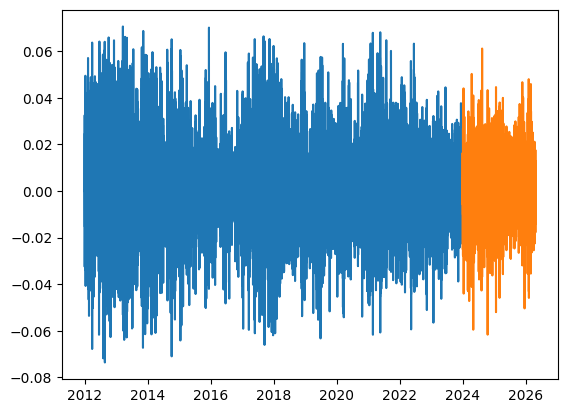

In [14]:
plt.plot(df_train["second_return"])
plt.plot(df_test["second_return"])

Calculating and ploting volatility and mean in weakly windows

In [15]:
df_train_volatility_w = df_train["second_return"].rolling(24*7).std()
df_train_return_mean_w = df_train["second_return"].rolling(24*7).mean()

df_test_volatility_w = df_test["second_return"].rolling(24*7).std()
df_test_return_mean_w = df_test["second_return"].rolling(24*7).mean()

Text(0.5, 1.0, 'weakly window $\\sigma^2$')

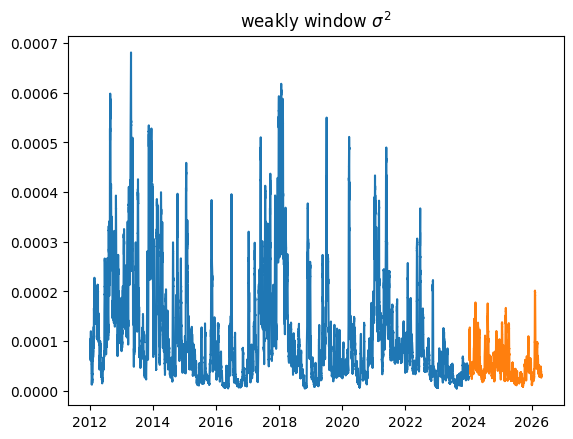

In [16]:
plt.plot((df_train_volatility_w)**2)
plt.plot((df_test_volatility_w)**2)
plt.title(r"weakly window $\sigma^2$")

Text(0.5, 1.0, 'weakly window $\\mu$')

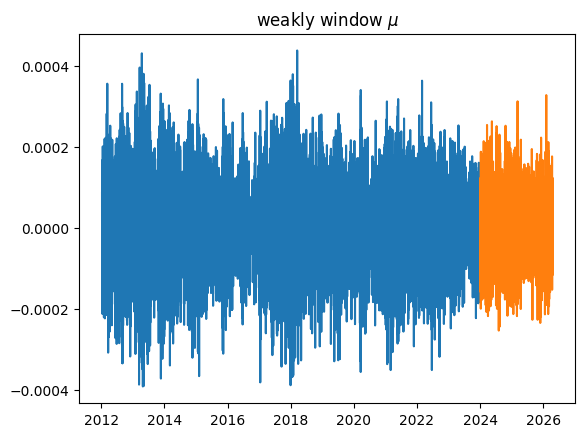

In [17]:
plt.plot(df_train_return_mean_w)
plt.plot(df_test_return_mean_w)
plt.title(r"weakly window $\mu$")

Copy and save data

In [18]:
df_train_final = df_train.copy()
df_test_final  = df_test.copy()

In [19]:
df_test_final.to_csv("test_bitcoin_processed.csv", index=True)
df_train_final.to_csv("train_bitcoin_processed.csv", index=True)

In [20]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, name="series"):
    print(f"\n===== Stationarity tests for {name} =====")
    adf_stat, adf_p, _, _, _, _ = adfuller(series)

    print(f"\nADF Test:\nStatistic: {adf_stat:.6f}\np-value:   {adf_p:.6f}")
    if adf_p < 0.05:
        print(" === Reject H0 (unit root) ⇒ likely STATIONARY ===")
    else:
        print(" === Fail to reject H0 ⇒ NON-stationary ===")


    kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")

    print(f"\nKPSS Test:\nStatistic: {kpss_stat:.6f}\np-value:   {kpss_p:.6f}")

    if kpss_p < 0.05:
        print(" === Reject H0 (stationarity) ⇒ NON-stationary ===")
    else:
        print(" === Fail to reject H0 ⇒ likely STATIONARY ===\n\n")

stationarity_tests(df_train_final["return"], "train returns")
stationarity_tests(df_test_final["return"], "test returns")


===== Stationarity tests for train returns =====

ADF Test:
Statistic: -45.401377
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 1.161839
p-value:   0.010000
 === Reject H0 (stationarity) ⇒ NON-stationary ===

===== Stationarity tests for test returns =====


C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")



ADF Test:
Statistic: -143.732696
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.296806
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===




C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")


the resunts of KPSS test on return train set is "Reject H0 (stationarity) ⇒ NON-stationary" so we try with second differentiation. After testing this feature we finally get likely stationaty data on both train and test set in both tests.

In [21]:
stationarity_tests(df_train_final["second_return"], "train second_return")
stationarity_tests(df_test_final["second_return"], "test second_return")


===== Stationarity tests for train second_return =====

ADF Test:
Statistic: -66.664935
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.009193
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===



===== Stationarity tests for test second_return =====


C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")



ADF Test:
Statistic: -37.095384
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.008160
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===




C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")


# 2. Modelling

In [22]:
print(df_train[:-1])

                        Close    return         trend   detrended  \
Timestamp                                                           
2012-01-01 12:00:00      4.58  0.000000      4.580000    0.000000   
2012-01-01 13:00:00      4.58  0.000000      4.580000    0.000000   
2012-01-01 14:00:00      4.58  0.000000      4.580000    0.000000   
2012-01-01 15:00:00      4.58  0.000000      4.580000    0.000000   
2012-01-01 16:00:00      4.58  0.000000      4.580000    0.000000   
...                       ...       ...           ...         ...   
2024-01-01 18:00:00  42723.00  0.001710  42608.645836  114.354164   
2024-01-01 19:00:00  42611.00 -0.002625  42608.673696    2.326304   
2024-01-01 20:00:00  42766.00  0.003631  42610.535545  155.464455   
2024-01-01 21:00:00  42727.00 -0.000912  42611.913823  115.086177   
2024-01-01 22:00:00  42817.00  0.002104  42614.340878  202.659122   

                     second_return  
Timestamp                           
2012-01-01 12:00:00       0.

Train size: 104156
Test size: 20226


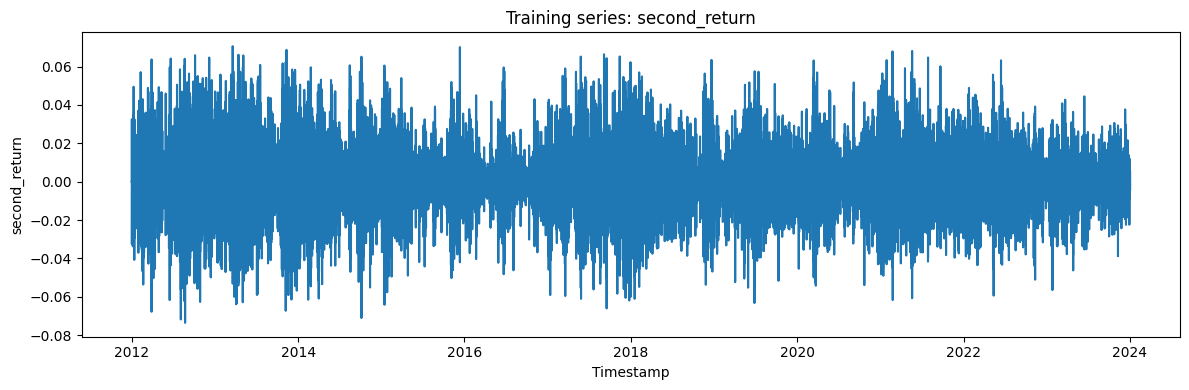

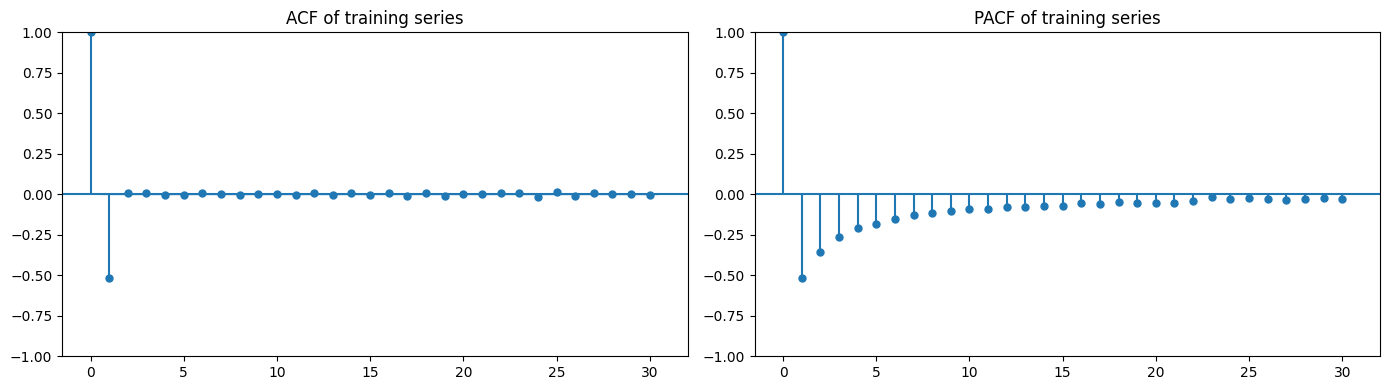


Top ARIMA candidates by AIC:
   p  d  q            AIC
0  0  0  2 -729392.484004
1  2  0  3 -727963.145737
2  0  0  3 -727026.126060
3  1  0  2 -726541.392152
4  3  0  3 -726057.847702
5  1  0  3 -725932.306539
6  2  0  2 -722482.236431
7  3  0  2 -722345.858733
8  2  0  1 -719491.645902
9  3  0  1 -716925.504235

Best ARIMA order: (0, 0, 2)
Best AIC: -729392.4840


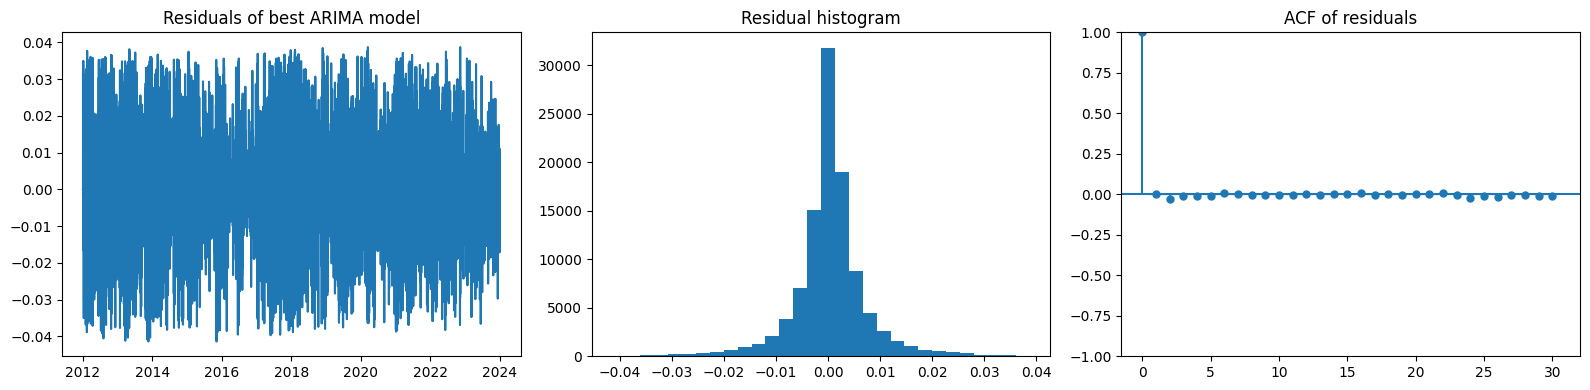

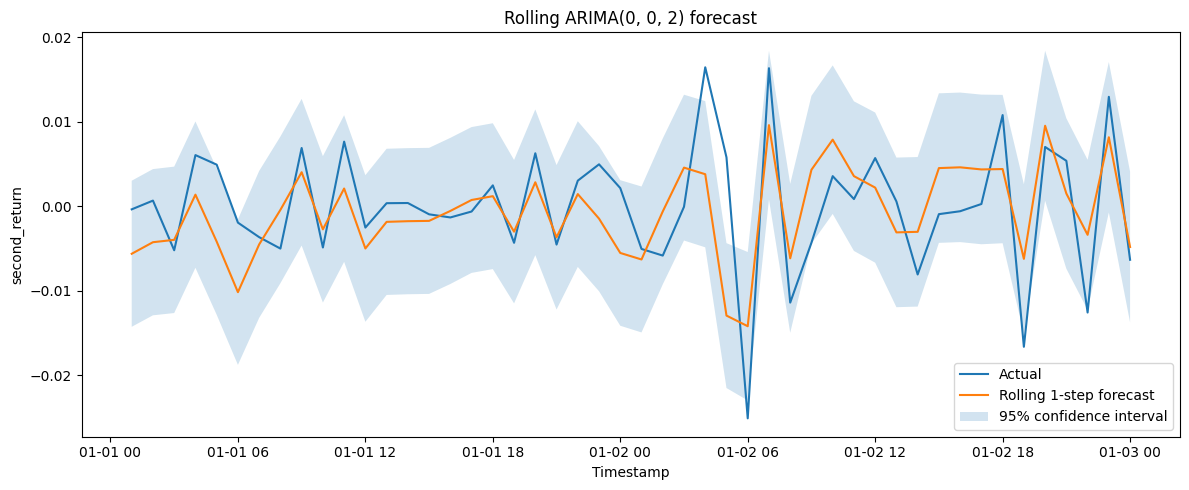


Forecast evaluation metrics:
                   Metric       Value
0                     MSE    0.000035
1                    RMSE    0.005925
2                     MAE    0.004756
3                MAPE (%)  362.668093
4               sMAPE (%)  114.406651
5  Direction accuracy (%)   72.916667


In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================
# 1. DATA
# =========================

df_train = df_train_final["second_return"]
df_final = df_test_final["second_return"]

train_series = df_train.astype(float).copy()
test_series = df_final.astype(float).copy()

# pełna seria do późniejszego refitu
full_series = pd.concat([train_series, test_series])

print(f"Train size: {len(train_series)}")
print(f"Test size: {len(test_series)}")


# =========================
# 2. ORIGINAL TRAIN SERIES
# =========================

plt.figure(figsize=(12, 4))
plt.plot(train_series.index, train_series.values)
plt.title("Training series: second_return")
plt.xlabel("Timestamp")
plt.ylabel("second_return")
plt.tight_layout()
plt.show()


# =========================
# 3. ACF AND PACF
# =========================
# Dane są już zróżnicowane i stacjonarne -> d = 0

d = 0
current_series = train_series.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(current_series.dropna(), lags=30, ax=axes[0])
axes[0].set_title("ACF of training series")

plot_pacf(current_series.dropna(), lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF of training series")

plt.tight_layout()
plt.show()


# =========================
# 4. SEARCH FOR p AND q BY AIC
# =========================

best_aic = np.inf
best_order = None
best_model = None
results_summary = []

p_values = range(0, 4)
q_values = range(0, 4)

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(train_series, order=(p, d, q))
            fitted_model = model.fit()

            aic_value = fitted_model.aic
            results_summary.append((p, d, q, aic_value))

            if aic_value < best_aic:
                best_aic = aic_value
                best_order = (p, d, q)
                best_model = fitted_model

        except Exception:
            continue

results_table = pd.DataFrame(results_summary, columns=["p", "d", "q", "AIC"])
results_table = results_table.sort_values("AIC").reset_index(drop=True)

print("\nTop ARIMA candidates by AIC:")
print(results_table.head(10))

print(f"\nBest ARIMA order: {best_order}")
print(f"Best AIC: {best_aic:.4f}")


# =========================
# 5. RESIDUALS
# =========================

residuals = pd.Series(best_model.resid, index=train_series.index[-len(best_model.resid):])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(residuals)
axes[0].set_title("Residuals of best ARIMA model")

axes[1].hist(residuals.dropna(), bins=30)
axes[1].set_title("Residual histogram")

plot_acf(residuals.dropna(), lags=30, ax=axes[2])
axes[2].set_title("ACF of residuals")

plt.tight_layout()
plt.show()


# =========================
# 6. ROLLING 1-STEP FORECAST ON TEST SET
# =========================

test_subset = test_series.iloc[:48].copy()   # 48 godzin
history = train_series.astype(float).iloc[-500:].tolist()

predictions = []
lower_bounds = []
upper_bounds = []

for t in range(len(test_subset)):
    model = ARIMA(history, order=best_order)
    fitted_model = model.fit()

    forecast_result = fitted_model.get_forecast(steps=1)
    forecast_mean = np.asarray(forecast_result.predicted_mean).reshape(-1)[0]
    forecast_ci = np.asarray(forecast_result.conf_int(alpha=0.05))

    predictions.append(float(forecast_mean))
    lower_bounds.append(float(forecast_ci[0, 0]))
    upper_bounds.append(float(forecast_ci[0, 1]))

    history.append(float(test_subset.iloc[t]))

rolling_forecast_df = pd.DataFrame({
    "actual": test_subset.values,
    "forecast": predictions,
    "lower_95": lower_bounds,
    "upper_95": upper_bounds
}, index=test_subset.index)

plt.figure(figsize=(12, 5))

plt.plot(rolling_forecast_df.index, rolling_forecast_df["actual"], label="Actual")
plt.plot(rolling_forecast_df.index, rolling_forecast_df["forecast"], label="Rolling 1-step forecast")

plt.fill_between(
    rolling_forecast_df.index,
    rolling_forecast_df["lower_95"],
    rolling_forecast_df["upper_95"],
    alpha=0.2,
    label="95% confidence interval"
)

plt.title(f"Rolling ARIMA{best_order} forecast")
plt.xlabel("Timestamp")
plt.ylabel("second_return")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 7. FORECAST EVALUATION METRICS
# =========================

actual = rolling_forecast_df["actual"].values
forecast = rolling_forecast_df["forecast"].values

mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, forecast)

# MAPE ostrożnie, bo second_return może być blisko 0
eps = 1e-8
mape = np.mean(np.abs((actual - forecast) / (actual + eps))) * 100

# sMAPE — lepsze dla wartości bliskich 0
smape = 100 * np.mean(
    2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast) + eps)
)

# kierunek zmiany: czy model dobrze przewidział znak
direction_accuracy = np.mean(np.sign(actual) == np.sign(forecast)) * 100

metrics_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "MAPE (%)", "sMAPE (%)", "Direction accuracy (%)"],
    "Value": [mse, rmse, mae, mape, smape, direction_accuracy]
})

print("\nForecast evaluation metrics:")
print(metrics_df)



# ====== just predictiong for 7 days
# test_subset = test_series.iloc[:500]   # albo np. [-500:] dla końcówki
# history = train_series.astype(float).tolist()

# predictions = []
# lower_bounds = []
# upper_bounds = []

# for t in range(len(test_subset)):
#     model = ARIMA(history, order=best_order)
#     fitted_model = model.fit()

#     forecast_result = fitted_model.get_forecast(steps=1)

#     forecast_mean = np.asarray(forecast_result.predicted_mean).reshape(-1)[0]
#     forecast_ci = np.asarray(forecast_result.conf_int(alpha=0.05))

#     predictions.append(float(forecast_mean))
#     lower_bounds.append(float(forecast_ci[0, 0]))
#     upper_bounds.append(float(forecast_ci[0, 1]))

#     history.append(float(test_subset.iloc[t]))

# rolling_forecast_df = pd.DataFrame({
#     "actual": test_subset.values,
#     "forecast": predictions,
#     "lower_95": lower_bounds,
#     "upper_95": upper_bounds
# }, index=test_subset.index)


# # =========================
# # 7. METRICS
# # =========================

# rmse = np.sqrt(mean_squared_error(rolling_forecast_df["actual"], rolling_forecast_df["forecast"]))
# mae = mean_absolute_error(rolling_forecast_df["actual"], rolling_forecast_df["forecast"])

# print(f"\nRolling forecast RMSE: {rmse:.6f}")
# print(f"Rolling forecast MAE:  {mae:.6f}")
# print("\nRolling forecast preview:")
# print(rolling_forecast_df.head())


# # =========================
# # 8. FORECAST VS ACTUAL PLOT
# # =========================

# plt.figure(figsize=(12, 5))
# plt.plot(train_series.index, train_series.values, label="Train")
# plt.plot(test_series.index, rolling_forecast_df["actual"], label="Test / Actual")
# plt.plot(test_series.index, rolling_forecast_df["forecast"], label="Rolling 1-step forecast")

# plt.fill_between(
#     test_series.index,
#     rolling_forecast_df["lower_95"],
#     rolling_forecast_df["upper_95"],
#     alpha=0.2,
#     label="95% confidence interval"
# )

# plt.title(f"Rolling ARIMA{best_order} forecast on test set")
# plt.xlabel("Timestamp")
# plt.ylabel("second_return")
# plt.legend()
# plt.tight_layout()
# plt.show()


# # =========================
# # 9. REFIT MODEL ON FULL DATA
# # =========================

# final_model = ARIMA(full_series, order=best_order).fit()


# # =========================
# # 10. FORECAST FOR NEXT DAY
# # =========================
# # Jeśli dane są godzinowe, to następny dzień = 24 kroki naprzód

# future_steps = 24
# future_forecast = final_model.get_forecast(steps=future_steps)

# future_mean = np.asarray(future_forecast.predicted_mean).reshape(-1)
# future_conf_int = np.asarray(future_forecast.conf_int(alpha=0.05))

# future_index = pd.date_range(
#     start=full_series.index[-1] + pd.Timedelta(hours=1),
#     periods=future_steps,
#     freq="H"
# )

# forecast_next_day = pd.DataFrame({
#     "forecast": future_mean,
#     "lower_95": future_conf_int[:, 0],
#     "upper_95": future_conf_int[:, 1]
# }, index=future_index)

# print("\nForecast for next day (24 hours ahead):")
# print(forecast_next_day)


# # =========================
# # 11. NEXT DAY FORECAST PLOT
# # =========================

# plt.figure(figsize=(12, 5))
# plt.plot(full_series.index[-200:], full_series.iloc[-200:], label="Historical second_return")
# plt.plot(forecast_next_day.index, forecast_next_day["forecast"], label="Next day forecast")

# plt.fill_between(
#     forecast_next_day.index,
#     forecast_next_day["lower_95"],
#     forecast_next_day["upper_95"],
#     alpha=0.2,
#     label="95% confidence interval"
# )

# plt.title(f"ARIMA{best_order} - forecast for next 24 hours")
# plt.xlabel("Timestamp")
# plt.ylabel("second_return")
# plt.legend()
# plt.tight_layout()
# plt.show()

GARCH

C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3254123521.py:38: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fitted_model = model.fit(disp="off")
C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3254123521.py:38: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fitted_model = model.fit(disp="off")
C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3254123521.py:38: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fitted_model = model.fit(disp="off")
C:\Users\weron\AppData\Local\Temp\ipykernel_5752\3254123521.py:38: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.op


Top GARCH candidates by AIC:
   p  q            AIC
0  1  3  252702.817512
1  2  3  252704.632695
2  3  3  252706.809888
3  1  2  254070.274428
4  2  2  254071.927834
5  3  2  254073.113372
6  1  1  256367.749773
7  2  1  256369.510707
8  3  1  256370.749508

Best GARCH order: (1, 3)
Best AIC: 252702.8175
                     Constant Mean - GARCH Model Results                      
Dep. Variable:          second_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -126345.
Distribution:                  Normal   AIC:                           252703.
Method:            Maximum Likelihood   BIC:                           252760.
                                        No. Observations:               104156
Date:                Fri, Apr 24 2026   Df Residuals:                   104155
Time:                        21:50:46   Df Model:           

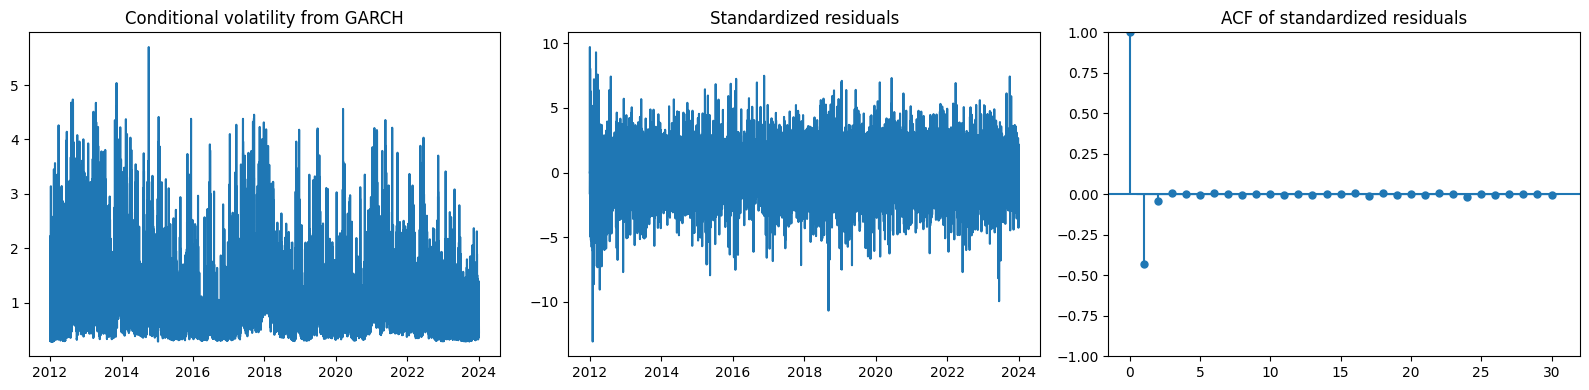

In [24]:

# !pip install arch

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# 7. GARCH VOLATILITY MODEL
# =========================

# GARCH zwykle lepiej działa, gdy zwroty są przeskalowane np. *100
train_garch = train_series.dropna() * 100
test_garch = test_series.dropna() * 100

# =========================
# 8. SEARCH FOR GARCH(p, q) BY AIC
# =========================

best_aic = np.inf
best_order_garch = None
best_garch_model = None
garch_results = []

p_values = range(1, 4)
q_values = range(1, 4)

for p in p_values:
    for q in q_values:
        try:
            model = arch_model(
                train_garch,
                mean="Constant",
                vol="GARCH",
                p=p,
                q=q,
                dist="normal"
            )

            fitted_model = model.fit(disp="off")

            aic_value = fitted_model.aic
            garch_results.append((p, q, aic_value))

            if aic_value < best_aic:
                best_aic = aic_value
                best_order_garch = (p, q)
                best_garch_model = fitted_model

        except Exception:
            continue

garch_results_table = pd.DataFrame(
    garch_results,
    columns=["p", "q", "AIC"]
).sort_values("AIC").reset_index(drop=True)

print("\nTop GARCH candidates by AIC:")
print(garch_results_table.head(10))

print(f"\nBest GARCH order: {best_order_garch}")
print(f"Best AIC: {best_aic:.4f}")

print(best_garch_model.summary())


# =========================
# 9. GARCH RESIDUALS AND CONDITIONAL VOLATILITY
# =========================

conditional_volatility = best_garch_model.conditional_volatility
standardized_residuals = best_garch_model.std_resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(conditional_volatility)
axes[0].set_title("Conditional volatility from GARCH")

axes[1].plot(standardized_residuals)
axes[1].set_title("Standardized residuals")

plot_acf(standardized_residuals.dropna(), lags=30, ax=axes[2])
axes[2].set_title("ACF of standardized residuals")

plt.tight_layout()
plt.show()


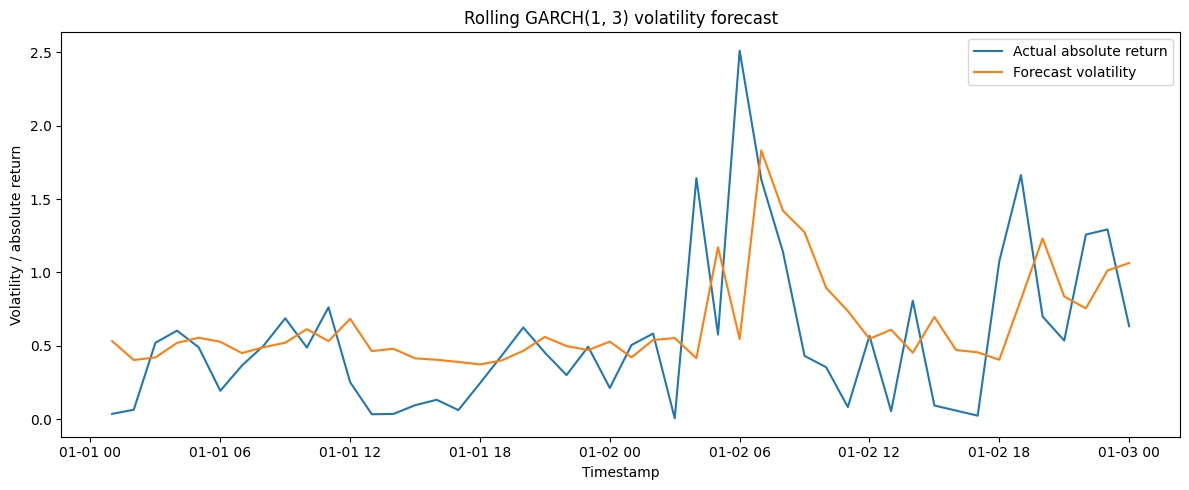

In [25]:
# =========================
# 10. ROLLING 1-STEP VOLATILITY FORECAST
# =========================

test_subset_garch = test_garch.iloc[:48].copy()
history_garch = train_garch.iloc[-500:].copy()

vol_predictions = []
variance_predictions = []

for t in range(len(test_subset_garch)):
    model = arch_model(
        history_garch,
        mean="Constant",
        vol="GARCH",
        p=best_order_garch[0],
        q=best_order_garch[1],
        dist="normal"
    )

    fitted_model = model.fit(disp="off")

    forecast = fitted_model.forecast(horizon=1)

    predicted_variance = forecast.variance.iloc[-1, 0]
    predicted_volatility = np.sqrt(predicted_variance)

    variance_predictions.append(predicted_variance)
    vol_predictions.append(predicted_volatility)

    history_garch = pd.concat([
        history_garch,
        pd.Series([test_subset_garch.iloc[t]], index=[test_subset_garch.index[t]])
    ])

volatility_forecast_df = pd.DataFrame({
    "actual_return": test_subset_garch.values,
    "forecast_variance": variance_predictions,
    "forecast_volatility": vol_predictions,
    "actual_squared_return": test_subset_garch.values ** 2,
    "actual_abs_return": np.abs(test_subset_garch.values)
}, index=test_subset_garch.index)

plt.figure(figsize=(12, 5))

plt.plot(
    volatility_forecast_df.index,
    volatility_forecast_df["actual_abs_return"],
    label="Actual absolute return"
)

plt.plot(
    volatility_forecast_df.index,
    volatility_forecast_df["forecast_volatility"],
    label="Forecast volatility"
)

plt.title(f"Rolling GARCH{best_order_garch} volatility forecast")
plt.xlabel("Timestamp")
plt.ylabel("Volatility / absolute return")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# =========================
# 11. VOLATILITY FORECAST METRICS
# =========================

actual_vol_proxy = volatility_forecast_df["actual_abs_return"].values
forecast_vol = volatility_forecast_df["forecast_volatility"].values

actual_var_proxy = volatility_forecast_df["actual_squared_return"].values
forecast_var = volatility_forecast_df["forecast_variance"].values

mae_vol = mean_absolute_error(actual_vol_proxy, forecast_vol)
mse_vol = mean_squared_error(actual_vol_proxy, forecast_vol)
rmse_vol = np.sqrt(mse_vol)

mae_var = mean_absolute_error(actual_var_proxy, forecast_var)
mse_var = mean_squared_error(actual_var_proxy, forecast_var)
rmse_var = np.sqrt(mse_var)

eps = 1e-8
mape_vol = np.mean(np.abs((actual_vol_proxy - forecast_vol) / (actual_vol_proxy + eps))) * 100

metrics_garch_df = pd.DataFrame({
    "Metric": [
        "MAE volatility",
        "MSE volatility",
        "RMSE volatility",
        "MAPE volatility (%)",
        "MAE variance",
        "MSE variance",
        "RMSE variance"
    ],
    "Value": [
        mae_vol,
        mse_vol,
        rmse_vol,
        mape_vol,
        mae_var,
        mse_var,
        rmse_var
    ]
})

print("\nGARCH volatility forecast metrics:")
print(metrics_garch_df)

metrics_garch_df


GARCH volatility forecast metrics:
                Metric       Value
0       MAE volatility    0.377653
1       MSE volatility    0.258525
2      RMSE volatility    0.508453
3  MAPE volatility (%)  408.455682
4         MAE variance    0.551787
5         MSE variance    1.195816
6        RMSE variance    1.093534


,Metric,Value
0,MAE volatility,0.377653
1,MSE volatility,0.258525
2,RMSE volatility,0.508453
3,MAPE volatility (%),408.455682
4,MAE variance,0.551787
5,MSE variance,1.195816
6,RMSE variance,1.093534


# ML

In [29]:
# =========================
# 7. ML ROLLING 1-STEP FORECAST
# Random Forest + Gradient Boosting
# =========================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# liczba opóźnień jako cechy
n_lags = 24

def make_features_from_history(history, n_lags=24):
    history = pd.Series(history).astype(float)

    features = {}

    for lag in range(1, n_lags + 1):
        features[f"lag_{lag}"] = history.iloc[-lag]

    features["rolling_mean_6"] = history.iloc[-6:].mean()
    features["rolling_std_6"] = history.iloc[-6:].std()

    features["rolling_mean_24"] = history.iloc[-24:].mean()
    features["rolling_std_24"] = history.iloc[-24:].std()

    features["rolling_min_24"] = history.iloc[-24:].min()
    features["rolling_max_24"] = history.iloc[-24:].max()

    return pd.DataFrame([features])


def make_supervised_dataset(series, n_lags=24):
    series = pd.Series(series).astype(float).reset_index(drop=True)

    rows = []
    targets = []

    for i in range(n_lags, len(series)):
        past = series.iloc[:i]
        X_i = make_features_from_history(past, n_lags=n_lags)
        rows.append(X_i)
        targets.append(series.iloc[i])

    X = pd.concat(rows, ignore_index=True)
    y = pd.Series(targets)

    return X, y

In [31]:
# =========================
# 8. MODELS
# =========================

ml_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    )
}

# =========================
# 9. ROLLING WINDOW FORECAST
# =========================

test_subset = test_series.iloc[:48].copy()

window_size = 500   # tak jak w ARIMA
ml_predictions = {}

for model_name, model in ml_models.items():

    history = train_series.astype(float).copy()
    predictions = []

    for t in range(len(test_subset)):

        train_window = history.iloc[-window_size:].copy()

        X_train_ml, y_train_ml = make_supervised_dataset(
            train_window,
            n_lags=n_lags
        )

        X_next = make_features_from_history(
            train_window,
            n_lags=n_lags
        )

        model.fit(X_train_ml, y_train_ml)

        pred = model.predict(X_next)[0]
        predictions.append(pred)

        history = pd.concat([
            history,
            pd.Series(
                [test_subset.iloc[t]],
                index=[test_subset.index[t]]
            )
        ])

    ml_predictions[model_name] = predictions
# =========================
# 10. ML FORECAST DATAFRAME
# =========================

ml_forecast_df = pd.DataFrame({
    "actual": test_subset.values
}, index=test_subset.index)

for model_name, preds in ml_predictions.items():
    ml_forecast_df[model_name] = preds

ml_forecast_df.head()

,actual,Random Forest,Gradient Boosting
Timestamp,,,
2024-01-01 01:00:00,-0.000377,-0.006177,-0.008076
2024-01-01 02:00:00,0.000657,-0.004074,-0.004187
2024-01-01 03:00:00,-0.005217,-0.004298,-0.004890
2024-01-01 04:00:00,0.006041,0.001808,0.001194
2024-01-01 05:00:00,0.004910,-0.005808,-0.005561


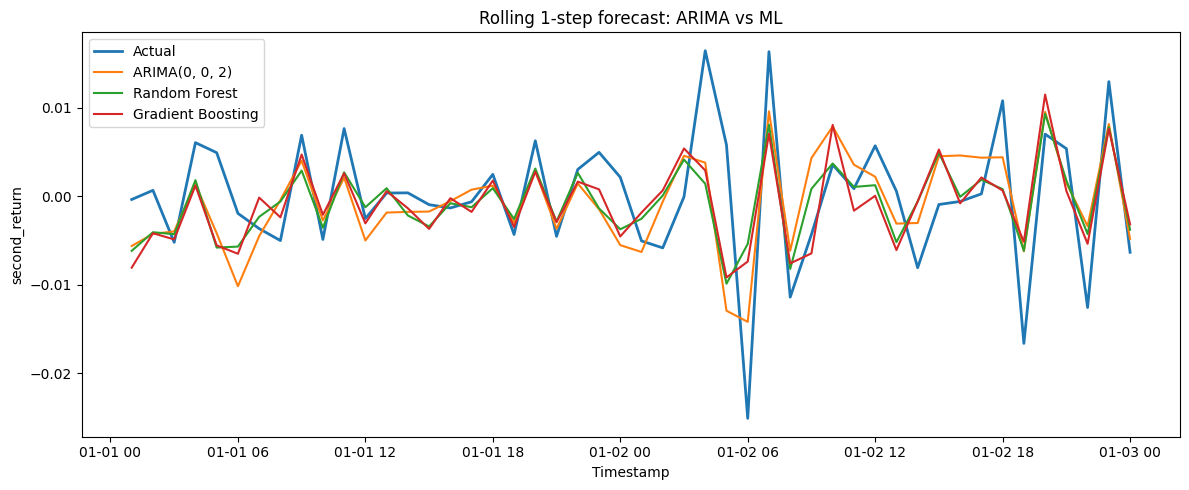

In [32]:
# =========================
# 11. PLOT: ARIMA VS ML
# =========================

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_forecast_df.index,
    rolling_forecast_df["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    rolling_forecast_df.index,
    rolling_forecast_df["forecast"],
    label=f"ARIMA{best_order}"
)

for model_name in ml_models.keys():
    plt.plot(
        ml_forecast_df.index,
        ml_forecast_df[model_name],
        label=model_name
    )

plt.title("Rolling 1-step forecast: ARIMA vs ML")
plt.xlabel("Timestamp")
plt.ylabel("second_return")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# =========================
# 12. METRICS: ARIMA VS ML
# =========================

def calculate_forecast_metrics(actual, forecast, model_name):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, forecast)

    eps = 1e-8

    mape = np.mean(
        np.abs((actual - forecast) / (actual + eps))
    ) * 100

    smape = 100 * np.mean(
        2 * np.abs(forecast - actual) /
        (np.abs(actual) + np.abs(forecast) + eps)
    )

    direction_accuracy = np.mean(
        np.sign(actual) == np.sign(forecast)
    ) * 100

    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
        "Direction accuracy (%)": direction_accuracy
    }


metrics_list = []

metrics_list.append(
    calculate_forecast_metrics(
        rolling_forecast_df["actual"],
        rolling_forecast_df["forecast"],
        f"ARIMA{best_order}"
    )
)

for model_name in ml_models.keys():
    metrics_list.append(
        calculate_forecast_metrics(
            ml_forecast_df["actual"],
            ml_forecast_df[model_name],
            model_name
        )
    )

comparison_metrics_df = pd.DataFrame(metrics_list)
comparison_metrics_df = comparison_metrics_df.sort_values("RMSE").reset_index(drop=True)

print("\nForecast comparison metrics:")
print(comparison_metrics_df)

comparison_metrics_df


Forecast comparison metrics:
               Model       MSE      RMSE       MAE    MAPE (%)   sMAPE (%)  \
0     ARIMA(0, 0, 2)  0.000035  0.005925  0.004756  362.668093  114.406651   
1  Gradient Boosting  0.000039  0.006229  0.004862  360.657913  115.113280   
2      Random Forest  0.000039  0.006246  0.004640  302.520293  111.471165   

   Direction accuracy (%)  
0               72.916667  
1               79.166667  
2               77.083333  


,Model,MSE,RMSE,MAE,MAPE (%),sMAPE (%),Direction accuracy (%)
0,"ARIMA(0, 0, 2)",0.000035,0.005925,0.004756,362.668093,114.406651,72.916667
1,Gradient Boosting,0.000039,0.006229,0.004862,360.657913,115.113280,79.166667
2,Random Forest,0.000039,0.006246,0.004640,302.520293,111.471165,77.083333


# ML prophet

21:51:06 - cmdstanpy - INFO - Chain [1] start processing
21:51:11 - cmdstanpy - INFO - Chain [1] done processing


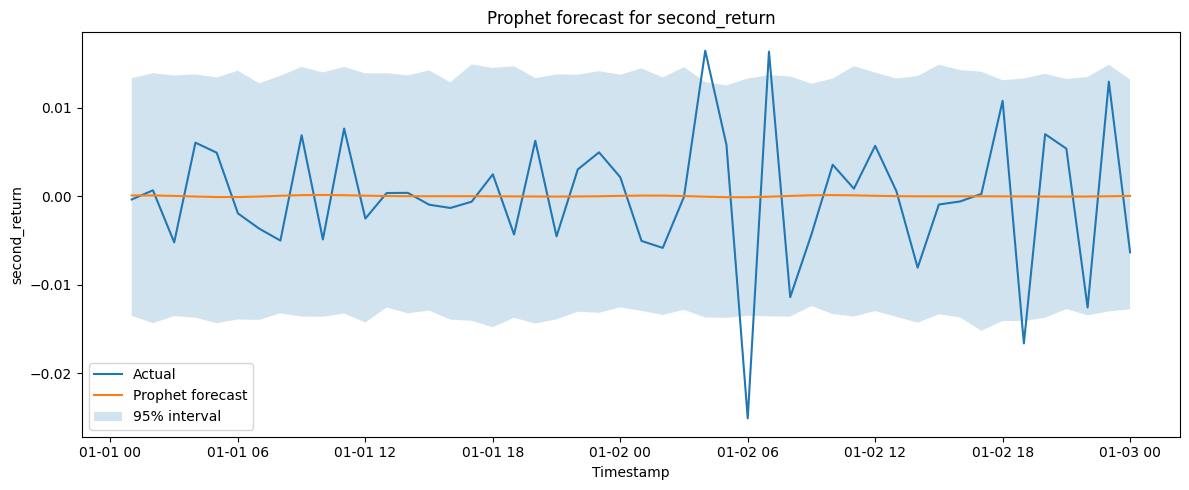

In [27]:
# =========================
# 17. PROPHET FORECAST
# =========================

# jeśli nie masz:
# !pip install prophet

from prophet import Prophet

prophet_train = train_series.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_test = test_series.iloc[:48].reset_index()
prophet_test.columns = ["ds", "y"]

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_train)

future = prophet_test[["ds"]]

prophet_forecast = prophet_model.predict(future)

prophet_forecast_df = pd.DataFrame({
    "actual": prophet_test["y"].values,
    "forecast": prophet_forecast["yhat"].values,
    "lower_95": prophet_forecast["yhat_lower"].values,
    "upper_95": prophet_forecast["yhat_upper"].values
}, index=prophet_test["ds"])


# =========================
# 18. PROPHET PLOT
# =========================

plt.figure(figsize=(12, 5))

plt.plot(
    prophet_forecast_df.index,
    prophet_forecast_df["actual"],
    label="Actual"
)

plt.plot(
    prophet_forecast_df.index,
    prophet_forecast_df["forecast"],
    label="Prophet forecast"
)

plt.fill_between(
    prophet_forecast_df.index,
    prophet_forecast_df["lower_95"],
    prophet_forecast_df["upper_95"],
    alpha=0.2,
    label="95% interval"
)

plt.title("Prophet forecast for second_return")
plt.xlabel("Timestamp")
plt.ylabel("second_return")
plt.legend()
plt.tight_layout()
plt.show()




In [28]:
# =========================
# 19. PROPHET METRICS
# =========================

actual = prophet_forecast_df["actual"].values
forecast = prophet_forecast_df["forecast"].values

mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, forecast)

eps = 1e-8
mape = np.mean(np.abs((actual - forecast) / (actual + eps))) * 100

smape = 100 * np.mean(
    2 * np.abs(forecast - actual) /
    (np.abs(actual) + np.abs(forecast) + eps)
)

direction_accuracy = np.mean(
    np.sign(actual) == np.sign(forecast)
) * 100

prophet_metrics_df = pd.DataFrame({
    "Model": ["Prophet"],
    "MSE": [mse],
    "RMSE": [rmse],
    "MAE": [mae],
    "MAPE (%)": [mape],
    "sMAPE (%)": [smape],
    "Direction accuracy (%)": [direction_accuracy]
})

print("\nProphet forecast evaluation metrics:")
print(prophet_metrics_df)

prophet_metrics_df


Prophet forecast evaluation metrics:
     Model       MSE     RMSE       MAE    MAPE (%)   sMAPE (%)  \
0  Prophet  0.000057  0.00757  0.005496  100.377302  195.999326   

   Direction accuracy (%)  
0                   43.75  


,Model,MSE,RMSE,MAE,MAPE (%),sMAPE (%),Direction accuracy (%)
0,Prophet,0.000057,0.00757,0.005496,100.377302,195.999326,43.75
